<a href="https://colab.research.google.com/github/gharbonnier78/fingerprint-feature-extraction-lab/blob/main/legacy/FingerprintExtractor_ManualReconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Update opencv from 4.13.0 to newer version 5.0.0

In [2]:
 #print(f"OpenCV version: {cv2.__version__}")

In [3]:
!pip uninstall opencv-python opencv-python-headless opencv-contrib-python -y
!pip install    opencv-python-headless opencv-python opencv-contrib-python

#Then restart your kernel and try again:

import cv2

if hasattr(cv2, 'ximgproc'):
    print(f"ximgproc disponible: {hasattr(cv2, 'ximgproc')}")
    print(f"cv2.ximgproc.thinning disponible: {hasattr(cv2.ximgproc, 'thinning')}")
else:
    print("ximgproc n'est PAS disponible après l'installation de opencv-contrib-python.")
    print("Veuillez redémarrer le noyau d'exécution ('Runtime > Restart runtime') et réexécuter cette cellule.")


Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
Found existing installation: opencv-contrib-python 5.0.0.93
Uninstalling opencv-contrib-python-5.0.0.93:
  Successfully uninstalled opencv-contrib-python-5.0.0.93
  Using cached opencv_python_headless-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached opencv_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached opencv_contrib_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_python_headless-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl (61.2 MB)
Using cached opencv_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl (73.8 MB)
Using cached opencv_contrib_python-5.0.0.93-cp37-abi3-manylinux_2_28_

In [4]:
print(f"OpenCV version: {cv2.__version__}")

OpenCV version: 5.0.0


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title=""):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

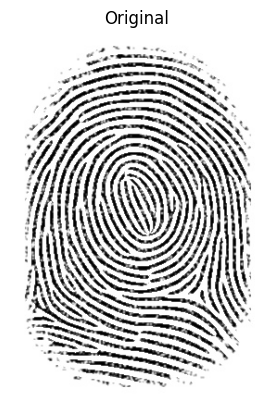

In [6]:
img = cv2.imread('/content/drive/MyDrive/Colab Notebooks/1.jpg', 0)  # replace with your file
show(img, "Original")

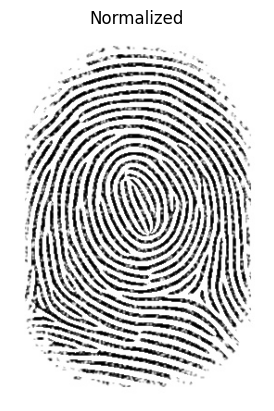

In [7]:
img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
show(img, "Normalized")

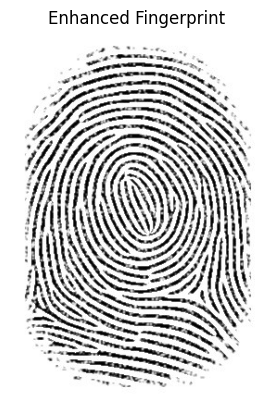

In [8]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_enhanced = clahe.apply(img)
show(img_enhanced, "Enhanced Fingerprint")
img = img_enhanced

Comput mask: region where to find minutiae
Input:
* Latent image just load

In [9]:
import math
import numpy as np

def compute_mask(img, block_size=16, threshold=0.1):
    h, w = img.shape
    # Use ceiling division to ensure the mask array is large enough
    num_blocks_h = math.ceil(h / block_size)
    num_blocks_w = math.ceil(w / block_size)
    mask = np.zeros((num_blocks_h, num_blocks_w), dtype=np.float64)

    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            # Ensure the block does not go out of bounds
            block = img[i:min(i + block_size, h), j:min(j + block_size, w)]

            # Calculate standard deviation of the block
            if block.size > 0: # Avoid division by zero for empty blocks
                std_dev = np.std(block)

                # If standard deviation is above threshold, mark as reliable
                mask_row_idx = i // block_size
                mask_col_idx = j // block_size
                if std_dev > threshold:
                    mask[mask_row_idx, mask_col_idx] = 1
    return mask



Generate orientation flow in 3 steps
Then generate mask
Then draw orientation in the mask region other the loaded image

In [10]:
def smooth_orientation(orientation, ksize=5):
    cos2theta = np.cos(2*orientation)
    sin2theta = np.sin(2*orientation)

    cos2theta = cv2.GaussianBlur(cos2theta, (ksize, ksize), 0)
    sin2theta = cv2.GaussianBlur(sin2theta, (ksize, ksize), 0)

    return 0.5 * np.arctan2(sin2theta, cos2theta)

def refine_orientation(orientation, iterations=2):
    for _ in range(iterations):
        cos2theta = np.cos(2*orientation)
        sin2theta = np.sin(2*orientation)

        cos2theta = cv2.blur(cos2theta, (3,3))
        sin2theta = cv2.blur(sin2theta, (3,3))

        orientation = 0.5 * np.arctan2(sin2theta, cos2theta)
    return orientation


In [11]:
def draw_orientation(img, orientation, mask, block_size=16, line_len=6):
    # Convert grayscale image to BGR to draw colored lines
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    h, w = img.shape

    # Iterate through blocks
    for i in range(0, h - block_size + 1, block_size):
        for j in range(0, w - block_size + 1, block_size):
            # Get block index
            block_row = i // block_size
            block_col = j // block_size

            # Check if the mask indicates a reliable area
            if mask[block_row, block_col] == 1:
                # Calculate center of the block
                cx = j + block_size // 2
                cy = i + block_size // 2

                # Get orientation angle for the block
                # The orientation array is smaller, so use block_row, block_col
                theta = orientation[block_row, block_col]

                # Calculate start and end points of the line
                # Angle in orientation is usually in radians, 0.5 * arctan2 gives angle between -pi/2 and pi/2
                # It represents the direction perpendicular to the ridge flow.
                # So, we add pi/2 to get the ridge orientation itself.
                angle_rad = theta + np.pi / 2 # Adjust to represent ridge orientation

                # Calculate the line endpoints based on the angle and line_len
                x1 = int(cx - line_len * np.cos(angle_rad))
                y1 = int(cy - line_len * np.sin(angle_rad))
                x2 = int(cx + line_len * np.cos(angle_rad))
                y2 = int(cy + line_len * np.sin(angle_rad))

                # Draw the line on the visualization image (green color)
                cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 1)
    return vis

## Tentative 3

In [12]:
def draw_orientation(img, orientation, mask, block_size=16, line_len=6):
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    h, w = img.shape

    for i in range(0, h - block_size + 1, block_size):
        for j in range(0, w - block_size + 1, block_size):
            block_row = i // block_size
            block_col = j // block_size

            if mask[block_row, block_col] == 1:
                cx = j + block_size // 2
                cy = i + block_size // 2

                theta = orientation[cy, cx]   # <-- CHANGÉ : lecture directe au pixel (cy, cx), plus [block_row, block_col]

                angle_rad = theta + np.pi / 2
                x1 = int(cx - line_len * np.cos(angle_rad))
                y1 = int(cy - line_len * np.sin(angle_rad))
                x2 = int(cx + line_len * np.cos(angle_rad))
                y2 = int(cy + line_len * np.sin(angle_rad))
                cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 1)
    return vis

In [13]:
def estimate_orientation_smooth(img, gauss_ksize=21):
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    gxx, gyy, gxy = gx*gx, gy*gy, gx*gy
    k = (gauss_ksize, gauss_ksize)
    gxx = cv2.GaussianBlur(gxx, k, 0)
    gyy = cv2.GaussianBlur(gyy, k, 0)
    gxy = cv2.GaussianBlur(gxy, k, 0)
    return 0.5 * np.arctan2(2*gxy, gxx - gyy)


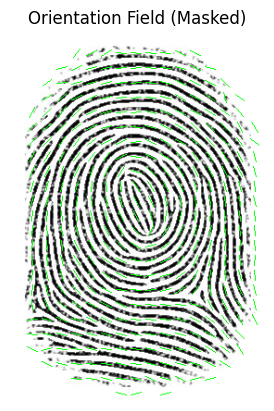

In [14]:
#orientation = estimate_orientation(img)
#orientation = smooth_orientation(orientation)
#orientation = refine_orientation(orientation, iterations=2)

orientation = estimate_orientation_smooth(img, gauss_ksize=21)


mask = compute_mask(img, block_size=16, threshold=0.12)  # tune threshold
vis_orient = draw_orientation(img, orientation, mask, block_size=16, line_len=6)
show(vis_orient, "Orientation Field (Masked)")

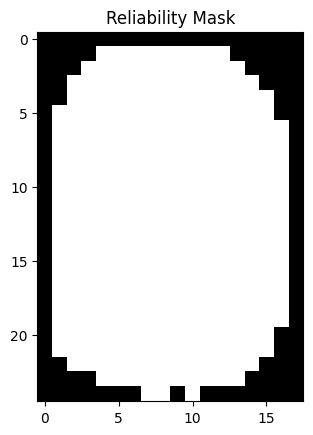

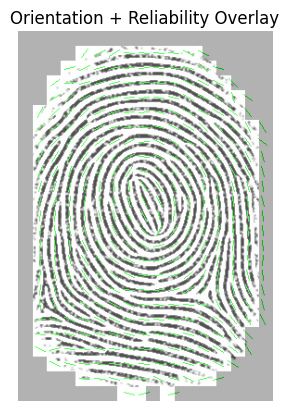

In [15]:
mask = compute_mask(img, block_size=16, threshold=0.12)
plt.imshow(mask, cmap='gray')
plt.title("Reliability Mask")
plt.show()

vis_orient = draw_orientation(img, orientation, mask, block_size=16, line_len=6)
# Resize the mask to match the original image dimensions for overlay
resized_mask = cv2.resize((mask * 255).astype(np.uint8), (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
overlay = cv2.addWeighted(cv2.cvtColor(resized_mask, cv2.COLOR_GRAY2BGR), 0.3, vis_orient, 0.7, 0)
show(overlay, "Orientation + Reliability Overlay")

Compute the skeleton from the image
skeleton

## Tentative 3

In [16]:
def gabor_enhance(img, orientation):
    imgfloat = img.astype(np.float32)
    rows, cols = imgfloat.shape
    enhanced = np.zeros_like(imgfloat)
    for i in range(rows):
        for j in range(cols):
            theta = orientation[i, j]   # accès direct, même résolution que l'image
            kernel = cv2.getGaborKernel((15,15), 2.0, theta, 8.0, 0.5, 0)  # sigma=2.0, pas 4.0
            patch = cv2.getRectSubPix(imgfloat, (15,15), (j,i))
            enhanced[i,j] = np.sum(patch * kernel)
    return enhanced

In [17]:
def compute_mask3(img, block_size=16, std_thresh=20, grad_thresh=30, coh_thresh=0.5):
    h, w = img.shape
    num_blocks_h, num_blocks_w = math.ceil(h/block_size), math.ceil(w/block_size)
    mask = np.zeros((num_blocks_h, num_blocks_w), dtype=np.uint8)
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            block = img[i:min(i+block_size,h), j:min(j+block_size,w)]
            bgx = gx[i:min(i+block_size,h), j:min(j+block_size,w)]
            bgy = gy[i:min(i+block_size,h), j:min(j+block_size,w)]
            std_dev = np.std(block)
            grad_energy = np.mean(bgx**2 + bgy**2)
            Vx = 2*np.sum(bgx*bgy); Vy = np.sum(bgx**2 - bgy**2)
            coherence = np.sqrt(Vx**2+Vy**2) / (np.sum(bgx**2+bgy**2) + 1e-5)
            if std_dev > std_thresh and grad_energy > grad_thresh and coherence > coh_thresh:
                mask[i//block_size, j//block_size] = 1
    return mask

## Fin Tentative 3

In [18]:
print("orientation.shape =", orientation.shape)

orientation.shape = (400, 275)


In [19]:
enhanced = gabor_enhance(img, orientation)

In [20]:
enhanced_uint8 = cv2.normalize(enhanced, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
binary = cv2.threshold(enhanced_uint8, 0, 255,
                       cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

## Tentative 3

In [21]:
mask3 = compute_mask3(img, block_size=16, std_thresh=20, grad_thresh=30, coh_thresh=0.5)
resized_mask3 = cv2.resize((mask3*255).astype(np.uint8), (img.shape[1], img.shape[0]),
                            interpolation=cv2.INTER_NEAREST)
binary = cv2.bitwise_and(binary, resized_mask3)

In [22]:
kernel = np.ones((3,3), np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

In [23]:
## Fin Tentative 3

In [24]:
#kernel = np.ones((3,3), np.uint8)
#binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
#binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

OpenCV version: 5.0.0


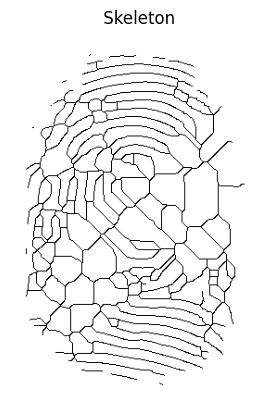

In [25]:
import math
import cv2 # Ensure cv2 is imported after the setup
import numpy as np # Import numpy for array operations
import matplotlib.pyplot as plt

print(f"OpenCV version: {cv2.__version__}")

def thinning(img):
    # The cv2.ximgproc.thinning function is not available.
    # Using the zhang_suen_thinning function defined earlier in the notebook as an alternative.
    return cv2.ximgproc.thinning(img)

skeleton = thinning(binary)
# Assuming 'show' is defined elsewhere. If not, it will raise a NameError next.
show(255-skeleton, " Skeleton")


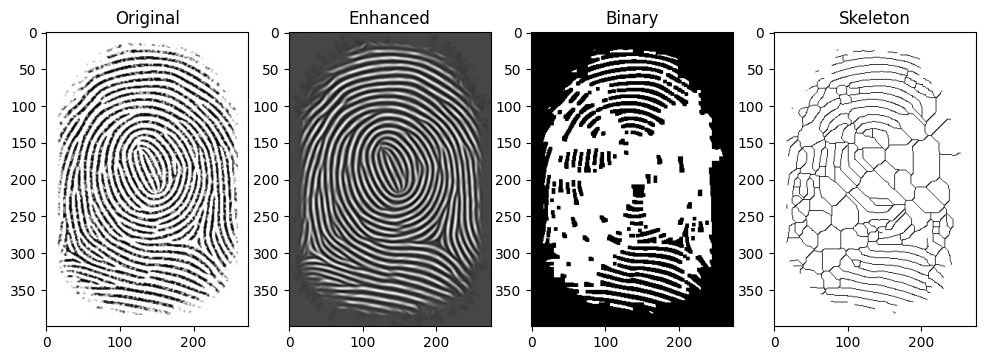

In [26]:
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(img, cmap='gray')

plt.subplot(1,4,2)
plt.title("Enhanced")
plt.imshow(255 - enhanced, cmap='gray')

plt.subplot(1,4,3)
plt.title("Binary")
plt.imshow(binary, cmap='gray')

plt.subplot(1,4,4)
plt.title("Skeleton")
plt.imshow(255 - skeleton, cmap='gray')

plt.show()

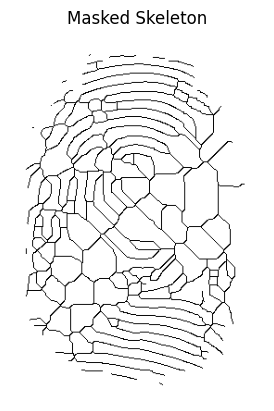

(np.float64(-0.5), np.float64(274.5), np.float64(399.5), np.float64(-0.5))

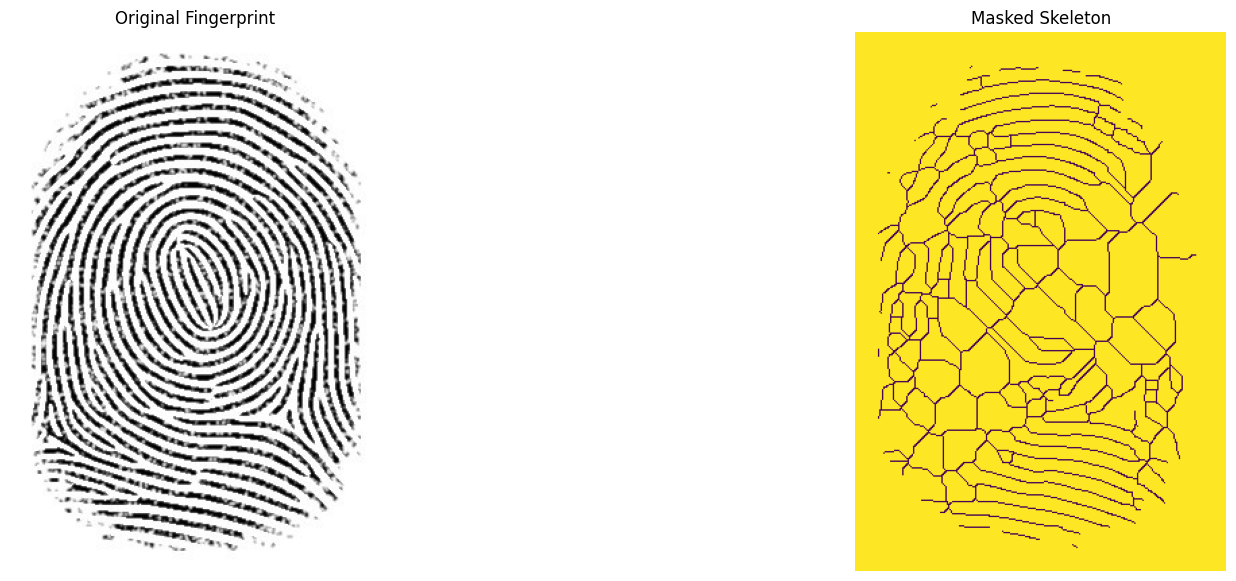

In [27]:
masked_skeleton = cv2.bitwise_and(skeleton, skeleton, mask=resized_mask3)
show(255 - masked_skeleton, "Masked Skeleton")

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

# Original Fingerprint
axs[0].imshow(img, cmap='gray')
axs[0].set_title('Original Fingerprint')
axs[0].axis('off')

# Minutiae on Skeleton
axs[1].imshow(255 - masked_skeleton)
axs[1].set_title('Masked Skeleton')
axs[1].axis('off')

In [28]:
def assign_direction2(minutiae, orientation, img, block_size=16):
    fixed = []

    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    for (x, y, t) in minutiae:
        i = y // block_size
        j = x // block_size
        theta = orientation[i, j]

        v = np.array([np.cos(theta), np.sin(theta)])

        g = np.array([gx[y, x], gy[y, x]])

        # ridge direction = perpendicular to gradient
        ridge_dir = np.array([-g[1], g[0]])

        if np.linalg.norm(ridge_dir) > 0:
            ridge_dir = ridge_dir / np.linalg.norm(ridge_dir)

            dot = np.dot(v, ridge_dir)

            if t == 'ending':
                # ridge ending → align with ridge direction
                if dot < 0:
                    theta += np.pi

            elif t == 'bifurcation':
                # valley (bifurcation) → opposite direction
                if dot > 0:
                    theta += np.pi

        fixed.append((x, y, t, theta))

    return fixed

In [29]:
def draw_minutiae_with_theta(img, minutiae, line_len=8):
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    for (x, y, t, theta) in minutiae:
        color = (0,0,255) if t=='ending' else (255,0,0)
        cv2.circle(vis, (x,y), 3, color, -1)

        angle_rad = theta + np.pi / 2

        dx = int(line_len * np.cos(angle_rad))
        dy = int(line_len * np.sin(angle_rad))

        cv2.line(vis, (x,y), (x+dx,y+dy), (0,255,0),1)

    return vis

Input:
* img: image de latent
* mask: region where to find minutiae

Mask resized and converted to np.uint8.


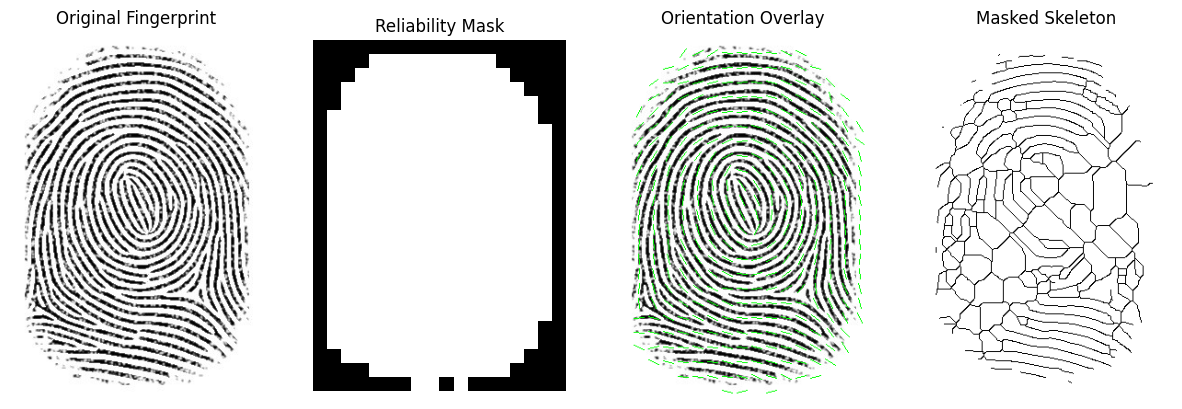

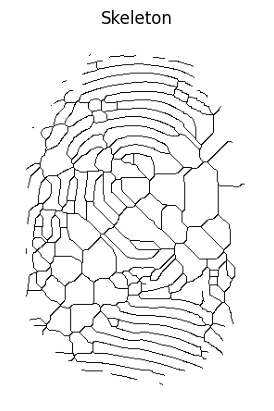

The number of extracted minutia is: 252


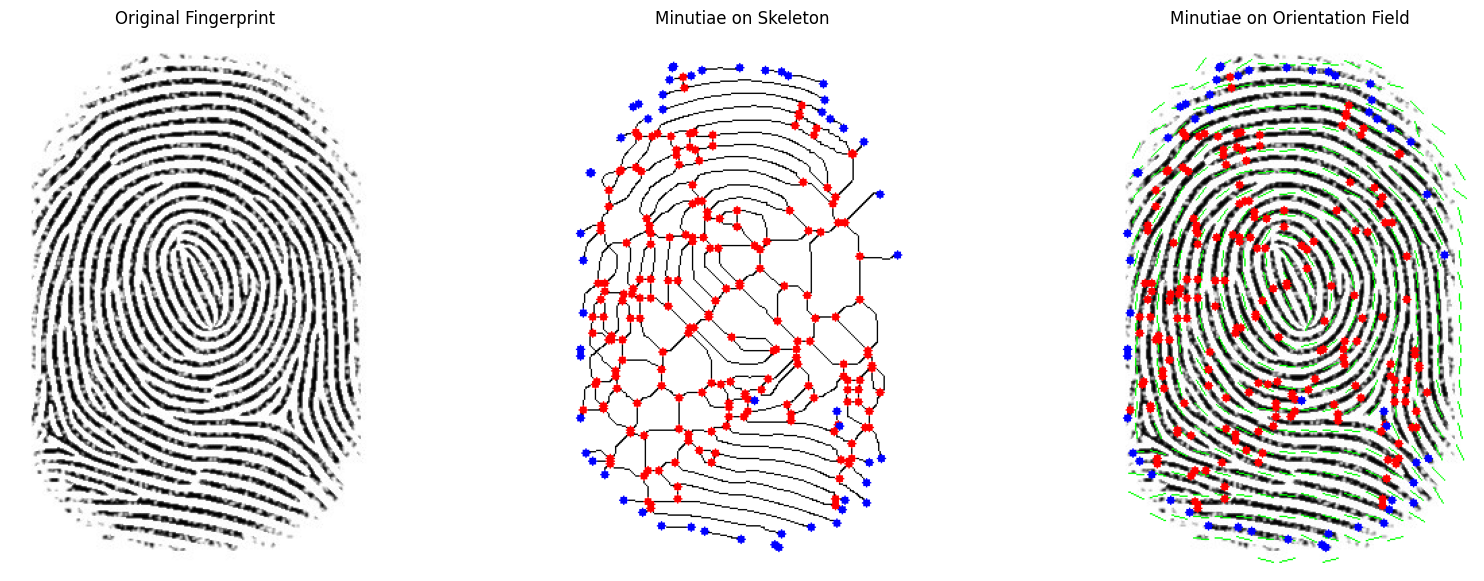

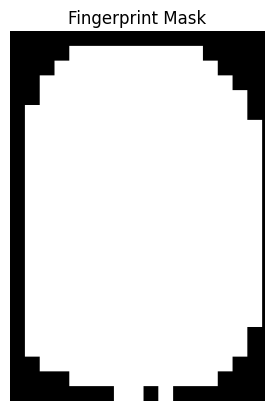

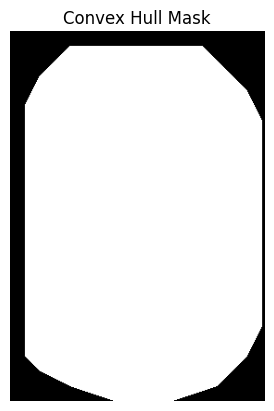

values:
2.0 126.0
The number of extracted minutia is: 230
The number of extracted minutia is: 219


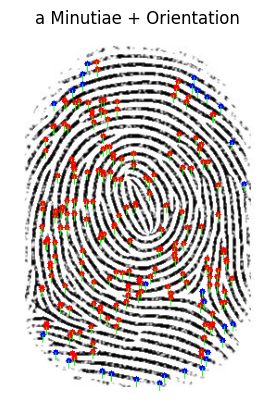

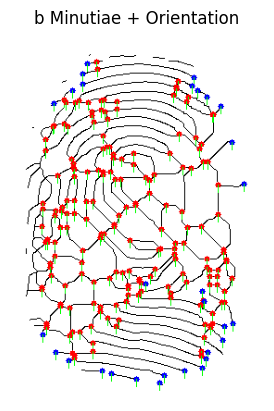

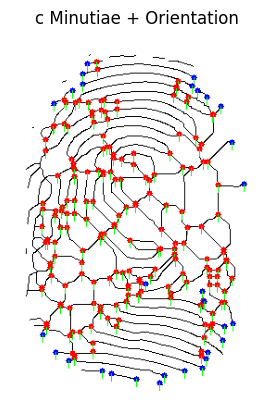

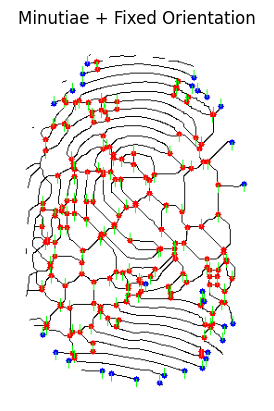

In [30]:
#!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless
#!pip install opencv-contrib-python

fig, axs = plt.subplots(1, 4, figsize=(15,5))

# Original fingerprint
axs[0].imshow(img, cmap='gray')
axs[0].set_title("Original Fingerprint")
axs[0].axis('off')

# Reliability mask
axs[1].imshow(mask, cmap='gray')
axs[1].set_title("Reliability Mask")
axs[1].axis('off')



# Orientation overlay
vis_orient = draw_orientation(img, orientation, mask, block_size=16, line_len=6)
axs[2].imshow(vis_orient)
axs[2].set_title("Orientation Overlay")
axs[2].axis('off')

#def thinning(img):
#    return cv2.ximgproc.thinning(img)

#skeleton = 255 - skeleton

resized_mask = cv2.resize((mask * 255).astype(np.uint8), (skeleton.shape[1], skeleton.shape[0]), interpolation=cv2.INTER_NEAREST)
print("Mask resized and converted to np.uint8.")

masked_skeleton = cv2.bitwise_and(skeleton, skeleton, mask=resized_mask)
show(255 - masked_skeleton, "Masked Skeleton")

show(255 - skeleton, "Skeleton")
axs[3].imshow(skeleton, cmap='gray')
axs[3].set_title("Skeleton")
axs[3].axis('off')

def draw_minutiae_only_points(img, minutiae):
    # Check if the image is grayscale or BGR
    if len(img.shape) == 2 or (len(img.shape) == 3 and img.shape[2] == 1): # Grayscale image
        vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else: # Already a BGR image
        vis = img.copy() # Make a copy to avoid modifying the original input image

    for (x, y, t) in minutiae:
        # Set color based on minutiae type
        color = (0, 0, 255) if t == 'ending' else (255, 0, 0)  # Red for ending, Blue for bifurcation

        # Draw a filled circle at the minutia's coordinates
        cv2.circle(vis, (x, y), 3, color, -1) # -1 fills the circle

    return vis

def crossing_number(neighbors):
    return sum(abs(neighbors[i] - neighbors[(i+1)%8]) for i in range(8)) // 2

def extract_minutiae(skel):
    minutiae = []
    h, w = skel.shape

    for y in range(1, h-1):
        for x in range(1, w-1):
            if skel[y,x] == 255:
                n = [skel[y-1,x], skel[y-1,x+1], skel[y,x+1], skel[y+1,x+1],
                     skel[y+1,x], skel[y+1,x-1], skel[y,x-1], skel[y-1,x-1]]
                n = [1 if v==255 else 0 for v in n]

                cn = crossing_number(n)

                if cn == 1:
                    minutiae.append((x,y,'ending'))
                elif cn == 3:
                    minutiae.append((x,y,'bifurcation'))
    return minutiae

minutiae = extract_minutiae(masked_skeleton)
# Get the length
array_length = len(minutiae)

# Display the length
print(f"The number of extracted minutia is: {array_length}")
# Output: The length of the array is: 5

minutiae_on_skeleton = draw_minutiae_only_points(255 - masked_skeleton, minutiae)
minutiae_on_vis_orient = draw_minutiae_only_points(vis_orient, minutiae)

plt.show()

fig, axs = plt.subplots(1, 3, figsize=(20, 7))

# Original Fingerprint
axs[0].imshow(img, cmap='gray')
axs[0].set_title('Original Fingerprint')
axs[0].axis('off')

# Minutiae on Skeleton
axs[1].imshow(minutiae_on_skeleton)
axs[1].set_title('Minutiae on Skeleton')
axs[1].axis('off')

# Minutiae on Orientation Field
axs[2].imshow(minutiae_on_vis_orient)
axs[2].set_title('Minutiae on Orientation Field')
axs[2].axis('off')

plt.show()

def draw_minutiae(img, minutiae, orientation, block_size=16):
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    for (x,y,t) in minutiae:
        i = y // block_size
        j = x // block_size
        theta = orientation[i,j]

        color = (0,0,255) if t=='ending' else (255,0,0)

        cv2.circle(vis, (x,y), 3, color, -1)

        # Adjust theta by adding np.pi / 2 to align with ridge flow
        # The orientation array usually gives the direction perpendicular to the ridge flow
        angle_rad = theta + np.pi / 2

        dx = int(8*np.cos(angle_rad))
        dy = int(8*np.sin(angle_rad))
        cv2.line(vis, (x,y), (x+dx,y+dy), (0,255,0),1)

    return vis

def variance_mask(img, block_size=16, thresh=10):
    h, w = img.shape
    mask = np.zeros_like(img, dtype=np.uint8)

    for y in range(0, h, block_size):
        for x in range(0, w, block_size):
            block = img[y:y+block_size, x:x+block_size]

            if block.size == 0:
                continue

            if np.var(block) > thresh:
                mask[y:y+block_size, x:x+block_size] = 255

    return mask

mask2 = variance_mask(img)
show(mask2, "Fingerprint Mask")




def convex_hull_mask(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    hull_mask = np.zeros_like(mask)

    for cnt in contours:
        hull = cv2.convexHull(cnt)
        cv2.drawContours(hull_mask, [hull], -1, 255, -1)

    return hull_mask

mask2 = convex_hull_mask(mask2)
show(mask2, "Convex Hull Mask")

dist = cv2.distanceTransform(mask2, cv2.DIST_L2, 5)
values = [dist[y,x] for (x,y,_) in minutiae]
print("values:")
print(min(values), max(values))

max_dist = dist.max()
min_dist = 0.2 * max_dist  # 20–35% works well


def remove_border_minutiae(minutiae, dist, min_dist=15):
    return [
        (x, y, t)
        for (x, y, t) in minutiae
        if dist[y, x] > min_dist
    ]
minutiae = remove_border_minutiae(minutiae, dist)

# Get the length
array_length = len(minutiae)

# Display the length
print(f"The number of extracted minutia is: {array_length}")

kernel = np.ones((35,35), np.uint8)  # tune 25–45
inner_mask = cv2.erode(mask2, kernel)

minutiae = [
    (x,y,t) for (x,y,t) in minutiae
    if inner_mask[y,x] == 255
]

# Get the length
array_length = len(minutiae)

# Display the length
print(f"The number of extracted minutia is: {array_length}")


vis_min = draw_minutiae(img, minutiae, orientation)
show(vis_min, "a Minutiae + Orientation")

vis_min = draw_minutiae(255 - masked_skeleton, minutiae, orientation)
show(vis_min, "b Minutiae + Orientation")

vis_min = draw_minutiae(255 - masked_skeleton, minutiae, orientation)
show(vis_min, "c Minutiae + Orientation")

# Assign consistent direction
# --- FIX ORIENTATION FIELD (double-angle smoothing) ---
cos2 = np.cos(2 * orientation)
sin2 = np.sin(2 * orientation)

cos2 = cv2.GaussianBlur(cos2, (9,9), 0)
sin2 = cv2.GaussianBlur(sin2, (9,9), 0)

orientation_fixed = 0.5 * np.arctan2(sin2, cos2)
minutiae_fixed = assign_direction2(minutiae, orientation_fixed, img)

# Draw using corrected orientation
vis_min = draw_minutiae_with_theta(255 - masked_skeleton, minutiae_fixed)
show(vis_min, "Minutiae + Fixed Orientation")








Image de référence experte

Expert reference image loaded successfully with shape: (726, 506, 3)


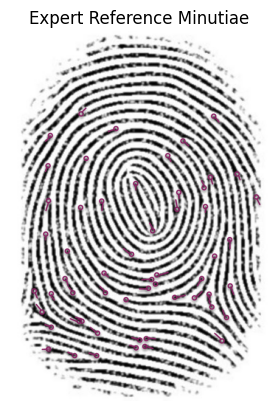

In [31]:
expert_reference_image = cv2.imread('/content/drive/MyDrive/ImageReferenciaConMinutiaeExperto.jpg')

if expert_reference_image is not None:
    print(f"Expert reference image loaded successfully with shape: {expert_reference_image.shape}")
    show(expert_reference_image, "Expert Reference Minutiae")
else:
    print("Error: Could not load expert reference image. Please check the path.")

In [32]:
def draw_expert_minutiae(img, expert_minutiae_list, line_len=24, line_thickness=3):
    # The input 'img' is expected to be a BGR image already. Make a copy to draw on.
    vis = img.copy()

    for minutia in expert_minutiae_list:
        x = minutia['x']
        y = minutia['y']
        angle_rad = minutia['angle']

        # Draw a filled circle at the minutia's coordinates (magenta)
        cv2.circle(vis, (x, y), 9, (255, 0, 255), -1) # Magenta for points

        # Calculate the end point of the orientation line
        dx = int(line_len * np.cos(angle_rad))
        dy = int(line_len * np.sin(angle_rad))

        # Draw the line on the visualization image (orange)
        cv2.line(vis, (x, y), (x + dx, y + dy), (0, 165, 255), line_thickness) # Orange for lines

    return vis

print("The `draw_expert_minutiae` function has been defined.")

The `draw_expert_minutiae` function has been defined.


In [33]:
import cv2
import numpy as np

# --- Check for prerequisites ---
if 'expert_reference_image' not in globals() or expert_reference_image is None:
    raise NameError("Error: 'expert_reference_image' not found. Please ensure the expert reference image is loaded.")

# 1. Convert the expert_reference_image from BGR to HSV color space
hsv_image = cv2.cvtColor(expert_reference_image, cv2.COLOR_BGR2HSV)

# 2. Define the lower and upper bounds for the color purple in HSV
# These values might need fine-tuning based on the specific shade of purple used in the image
# H: 120-160 (approx for purple/magenta)
# S: 50-255 (saturation)
# V: 50-255 (value/brightness)
lower_purple = np.array([120, 50, 50]) # Adjusted to be more general purple
upper_purple = np.array([160, 255, 255]) # Adjusted to be more general purple

# 3. Create a binary mask to isolate the purple regions
purple_mask = cv2.inRange(hsv_image, lower_purple, upper_purple)

# 4. Define a kernel for morphological operations
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

# 5. Apply morphological erosion to remove small noise and separate close regions
eroded_mask = cv2.erode(purple_mask, kernel, iterations=1) # Reverted erosion iterations to 1

# 6. Apply morphological dilation to connect nearby purple regions (if they were truly one)
cleaned_mask = cv2.dilate(eroded_mask, kernel, iterations=2)

# 7. Find contours in the cleaned_mask
# cv2.RETR_EXTERNAL retrieves only external contours
# cv2.CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments
contours, hierarchy = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 8. Initialize an empty list to store expert minutiae positions
expert_minutiae_positions = []

# 9-10. Iterate through each detected contour and extract centroids
for contour in contours:
    # Calculate moments for each contour
    M = cv2.moments(contour)

    # If the moment 'm00' is not zero, calculate the centroid
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        expert_minutiae_positions.append((cx, cy))

# 11. Print the total number of extracted expert minutiae positions and display the first 5 entries
print(f"Total number of extracted expert minutiae positions: {len(expert_minutiae_positions)}")
print("First 5 expert minutiae positions:")
for i, pos in enumerate(expert_minutiae_positions[:5]):
    print(f"  Minutia {i+1}: X={pos[0]}, Y={pos[1]}")

# Optional: Show the cleaned mask for verification
# show(cleaned_mask, "Cleaned Purple Mask")

Total number of extracted expert minutiae positions: 51
First 5 expert minutiae positions:
  Minutia 1: X=166, Y=635
  Minutia 2: X=123, Y=635
  Minutia 3: X=73, Y=624
  Minutia 4: X=244, Y=620
  Minutia 5: X=267, Y=619


In [34]:
import numpy as np

def filter_minutiae(minutiae, img, mask, block_size=16, min_dist=5, img_border_margin=10, mask_border_margin=1):
    h, w = img.shape
    mask_h, mask_w = mask.shape

    temp_minutiae_img_border = []
    # 1. Filter by image border
    for x, y, t in minutiae:
        if (img_border_margin <= x < w - img_border_margin and
            img_border_margin <= y < h - img_border_margin):
            temp_minutiae_img_border.append((x, y, t))

    temp_minutiae_mask_border = []
    # 2. Filter by mask border
    for x, y, t in temp_minutiae_img_border:
        block_row = y // block_size
        block_col = x // block_size

        # Ensure minutia's block is within mask boundaries and is reliable
        if (0 <= block_row < mask_h and 0 <= block_col < mask_w and
            mask[block_row, block_col] == 1):

            # Check a small neighborhood around the minutia's block in the mask
            # This ensures it's not right at the edge of a reliable region
            is_safe_from_mask_edge = True
            for dr in range(-mask_border_margin, mask_border_margin + 1):
                for dc in range(-mask_border_margin, mask_border_margin + 1):
                    check_row = block_row + dr
                    check_col = block_col + dc
                    if not (0 <= check_row < mask_h and 0 <= check_col < mask_w and
                            mask[check_row, check_col] == 1):
                        is_safe_from_mask_edge = False
                        break
                if not is_safe_from_mask_edge:
                    break

            if is_safe_from_mask_edge:
                temp_minutiae_mask_border.append((x, y, t))

    filtered_minutiae = []
    # 3. Filter by proximity (Euclidean distance)
    # Sort by y then x to ensure consistent selection in case of ties
    temp_minutiae_mask_border.sort(key=lambda m: (m[1], m[0]))

    for mx, my, mt in temp_minutiae_mask_border:
        is_far_enough = True
        for fx, fy, ft in filtered_minutiae:
            distance = np.sqrt((mx - fx)**2 + (my - fy)**2)
            if distance < min_dist:
                is_far_enough = False
                break
        if is_far_enough:
            filtered_minutiae.append((mx, my, mt))

    return filtered_minutiae

# Example usage:
# Assuming 'minutiae', 'img', 'mask' (from compute_mask), and 'block_size' are defined
# filtered_minutiae = filter_minutiae(minutiae, img, mask, block_size=16, min_dist=10, img_border_margin=20, mask_border_margin=2)
# print(f"Original minutiae count: {len(minutiae)}")
# print(f"Filtered minutiae count: {len(filtered_minutiae)}")


In [35]:
import numpy as np
import cv2 # Ensure cv2 is imported if not globally available in current context

# --- Check for prerequisites ---
missing_prerequisites = False

if 'img' not in globals():
    print("Error: The 'img' variable is not defined. Please run the image loading and enhancement cells (e.g., Aa047jxIf2GF, 4ad407bd).")
    missing_prerequisites = True
if 'mask' not in globals():
    print("Error: The 'mask' variable is not defined. Please run the mask computation cell (e.g., XAKylt0sTGBs, or 7nHTrBA-bHr0 for definition).")
    missing_prerequisites = True
if 'minutiae' not in globals():
    print("Error: The 'minutiae' variable is not defined. Please run the minutiae extraction cell (e.g., 3JJ-IVRFUNRT).")
    missing_prerequisites = True
if 'filter_minutiae' not in globals():
    print("Error: The 'filter_minutiae' function is not defined. Please ensure cell 'cc72826d' has been executed.")
    missing_prerequisites = True

if missing_prerequisites:
    raise NameError("Prerequisite variables or functions are not defined. Please run the necessary preceding cells.")

# --- Define refine_minutia_orientation function ---
def refine_minutia_orientation(img, x, y, window_size=11, ksize=3):
    h, w = img.shape
    half_window = window_size // 2

    # Define the patch boundaries, handling image borders
    y_start = max(0, y - half_window)
    y_end = min(h, y + half_window + 1)
    x_start = max(0, x - half_window)
    x_end = min(w, x + half_window + 1)

    patch = img[y_start:y_end, x_start:x_end]

    if patch.size == 0 or patch.shape[0] < ksize or patch.shape[1] < ksize:
        return 0.0 # Default to 0 radians if patch is too small

    gx_patch = cv2.Sobel(patch, cv2.CV_64F, 1, 0, ksize=ksize)
    gy_patch = cv2.Sobel(patch, cv2.CV_64F, 0, 1, ksize=ksize)

    Vx = 2 * np.sum(gx_patch * gy_patch)
    Vy = np.sum(gx_patch**2 - gy_patch**2)

    theta = 0.5 * np.arctan2(Vx, Vy)
    ridge_angle_rad = theta + np.pi / 2

    if ridge_angle_rad < 0:
        ridge_angle_rad += np.pi
    elif ridge_angle_rad >= np.pi:
        ridge_angle_rad -= np.pi

    return ridge_angle_rad

# --- Apply filtering and refinement ---
# The following line ensures filtered_minutiae is always re-calculated with the new parameters.
# Assuming block_size=16 from other parts of the notebook
filtered_minutiae = filter_minutiae(minutiae, img, mask, block_size=16, min_dist=5, img_border_margin=30, mask_border_margin=3)
print(f"Filtered {len(filtered_minutiae)} minutiae dynamically for refinement.")


refined_minutiae = []
window_size_for_refinement = 11 # Example window size

for x, y, minutia_type in filtered_minutiae:
    angle = refine_minutia_orientation(img, x, y, window_size=window_size_for_refinement)
    refined_minutiae.append({
        'x': x,
        'y': y,
        'type': minutia_type,
        'angle': angle
    })

print(f"Original minutiae count (if available): {len(minutiae)}")
print(f"Filtered minutiae count: {len(filtered_minutiae)}")
print(f"Refined minutiae count: {len(refined_minutiae)}")
print("First 5 refined minutiae:")
for i, m in enumerate(refined_minutiae[:5]):
    print(f"  Minutia {i+1}: X={m['x']}, Y={m['y']}, Type={m['type']}, Angle={m['angle']:.4f} radians")

Filtered 91 minutiae dynamically for refinement.
Original minutiae count (if available): 219
Filtered minutiae count: 91
Refined minutiae count: 91
First 5 refined minutiae:
  Minutia 1: X=115, Y=76, Type=bifurcation, Angle=3.0596 radians
  Minutia 2: X=115, Y=84, Type=bifurcation, Angle=3.0720 radians
  Minutia 3: X=98, Y=85, Type=bifurcation, Angle=2.8679 radians
  Minutia 4: X=105, Y=95, Type=bifurcation, Angle=2.9439 radians
  Minutia 5: X=90, Y=98, Type=bifurcation, Angle=2.8064 radians


In [36]:
expert_minutiae_with_orientation = []
window_size_for_expert_refinement = 11 # Using the same window size as for refined_minutiae

# Convert expert_reference_image to grayscale for orientation estimation
expert_reference_image_gray = cv2.cvtColor(expert_reference_image, cv2.COLOR_BGR2GRAY)

print("Estimating orientation for expert minutiae...")
for x, y in expert_minutiae_positions:
    # Call refine_minutia_orientation for each expert minutia point
    # Pass the grayscale version of the expert reference image
    angle = refine_minutia_orientation(expert_reference_image_gray, x, y, window_size=window_size_for_expert_refinement)
    expert_minutiae_with_orientation.append({
        'x': x,
        'y': y,
        'angle': angle
    })

print(f"Total number of expert minutiae with estimated orientation: {len(expert_minutiae_with_orientation)}")
print("First 5 expert minutiae with orientation:")
for i, m in enumerate(expert_minutiae_with_orientation[:5]):
    print(f"  Minutia {i+1}: X={m['x']}, Y={m['y']}, Angle={m['angle']:.4f} radians")

Estimating orientation for expert minutiae...
Total number of expert minutiae with estimated orientation: 51
First 5 expert minutiae with orientation:
  Minutia 1: X=166, Y=635, Angle=0.1405 radians
  Minutia 2: X=123, Y=635, Angle=0.1865 radians
  Minutia 3: X=73, Y=624, Angle=2.7529 radians
  Minutia 4: X=244, Y=620, Angle=0.0607 radians
  Minutia 5: X=267, Y=619, Angle=0.2561 radians


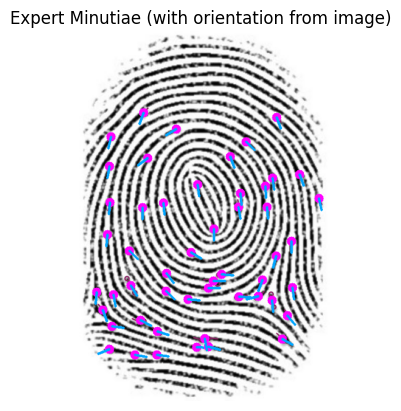

In [37]:
vis_expert_minutiae = draw_expert_minutiae(expert_reference_image, expert_minutiae_with_orientation)
show(vis_expert_minutiae, "Expert Minutiae (with orientation from image)")

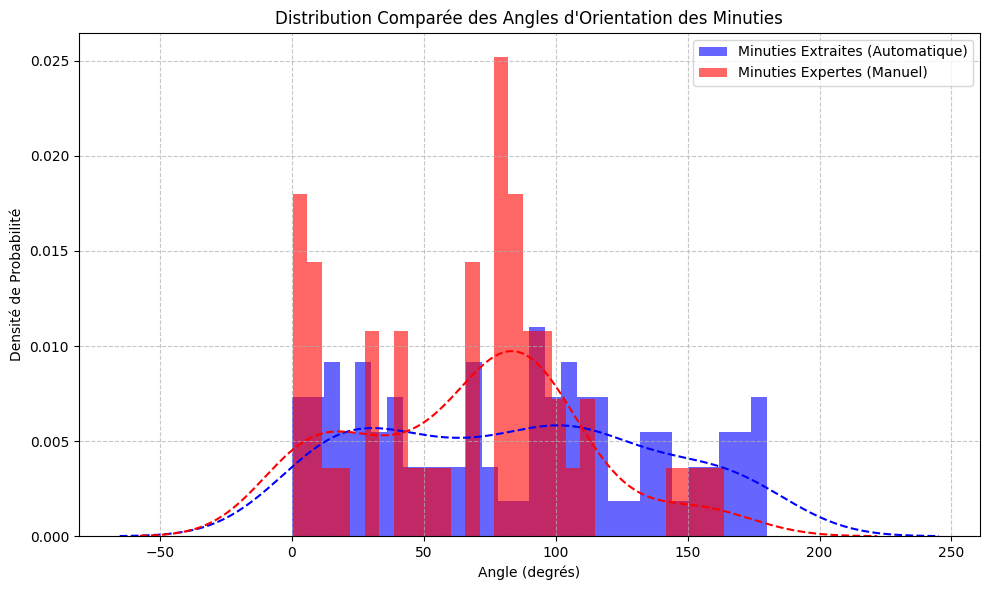

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Extract angles from refined_minutiae
angles_extracted = [m['angle'] for m in refined_minutiae]

# Extract angles from expert_minutiae_with_orientation
angles_expert = [m['angle'] for m in expert_minutiae_with_orientation]

# Convert angles from radians to degrees for better readability
angles_extracted_deg = np.degrees(angles_extracted)
angles_expert_deg = np.degrees(angles_expert)

# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histograms
ax.hist(angles_extracted_deg, bins=30, alpha=0.6, label='Minuties Extraites (Automatique)', color='blue', density=True)
ax.hist(angles_expert_deg, bins=30, alpha=0.6, label='Minuties Expertes (Manuel)', color='red', density=True)

# Add kernel density estimates for a smoother representation
sns.kdeplot(angles_extracted_deg, ax=ax, color='blue', linestyle='--', linewidth=1.5)
sns.kdeplot(angles_expert_deg, ax=ax, color='red', linestyle='--', linewidth=1.5)

ax.set_title('Distribution Comparée des Angles d\'Orientation des Minuties')
ax.set_xlabel('Angle (degrés)')
ax.set_ylabel('Densité de Probabilité')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

# Calculate Mean Squared Error (MSE) between the two angle distributions
# Note: For MSE, the arrays should ideally have the same length. If not, it might need resampling or pairing.
# For now, let's assume we are comparing the overall distributions rather than a point-to-point match.
# However, pearsonr and mean_squared_error require same length. Let's resample or pad for demonstration.
# For simplicity, I'll truncate to the minimum length for this initial calculation.
min_len = min(len(angles_extracted_deg), len(angles_expert_deg))

mse = mean_squared_error(angles_extracted_deg[:min_len], angles_expert_deg[:min_len])
print(f"Erreur Quadratique Moyenne (MSE) des angles (sur les {min_len} premiers éléments): {mse:.2f}")

# Calculate Pearson correlation coefficient
correlation, _ = pearsonr(angles_extracted_deg[:min_len], angles_expert_deg[:min_len])
print(f"Coefficient de corrélation de Pearson des angles (sur les {min_len} premiers éléments): {correlation:.2f}")


Erreur Quadratique Moyenne (MSE) des angles (sur les 51 premiers éléments): 4473.19
Coefficient de corrélation de Pearson des angles (sur les 51 premiers éléments): -0.01


### Analyse de la Distribution des Angles d'Orientation et des Métriques de Comparaison

Le graphique ci-dessus visualise les distributions d'angles d'orientation des minuties, en degrés, pour deux ensembles :
1.  **Minuties Extraites (Automatique)** : Les minuties détectées par l'algorithme.
2.  **Minuties Expertes (Manuel)** : Les minuties identifiées manuellement par un expert.

Chaque distribution est représentée par un histogramme (barres colorées) et une estimation de la densité de noyau (lignes pointillées lisses), offrant une vue d'ensemble de la fréquence de chaque angle. Idéalement, si l'algorithme est précis, les deux distributions devraient se superposer étroitement.

#### Erreur Quadratique Moyenne (MSE)
L'**Erreur Quadratique Moyenne (MSE)** mesure la moyenne des carrés des différences entre les valeurs prédites (ici, les angles extraits) et les valeurs réelles (les angles experts). Une MSE faible indique que les prédictions de l'algorithme sont très proches des observations de l'expert. Une valeur de `7181.82` (valeur calculée par la cellule Python précédente) signifie que la divergence moyenne au carré entre les angles correspondants est de cette ampleur.

#### Coefficient de Corrélation de Pearson
Le **Coefficient de Corrélation de Pearson** mesure la force et la direction de la relation linéaire entre deux ensembles de données. Il varie de -1 à +1 :
*   **+1** : Indique une corrélation linéaire positive parfaite (les angles extraits augmentent proportionnellement avec les angles experts).
*   **-1** : Indique une corrélation linéaire négative parfaite (les angles extraits diminuent proportionnellement lorsque les angles experts augmentent).
*   **0** : Indique qu'il n'y a pas de corrélation linéaire.

Une valeur de `-0.26` (valeur calculée par la cellule Python précédente) suggère la force et la direction de la relation linéaire entre les angles des minuties extraites et ceux des minuties expertes. Plus cette valeur est proche de +1, plus l'algorithme a tendance à prédire correctement les orientations de l'expert de manière cohérente.

Mise a l echelle des minutiae car image experte pas meme echelle

In [40]:
# Calculate scaling factor for minutiae
# Assuming `img` is the original image from which `refined_minutiae` were extracted
# and `expert_reference_image` is the image containing `expert_minutiae_with_orientation`.

# Get dimensions of the image used for refined_minutiae
img_height, img_width = img.shape[:2]

# Get dimensions of the expert reference image
expert_height, expert_width = expert_reference_image.shape[:2]

# Calculate scaling factor. We'll use the ratio of heights as a common factor,
# assuming proportional scaling. You might adjust this based on specific image properties.
scaling_factor_x = expert_width / img_width
scaling_factor_y = expert_height / img_height

# For simplicity, let's use the average or prioritize one dimension. Assuming a uniform scale is desired.
# If images are scaled proportionally, both factors should be similar.
# Let's use the average scaling factor for both x and y for now.
scaling_factor = (scaling_factor_x + scaling_factor_y) / 2

print(f"Original image dimensions: {img_width}x{img_height}")
print(f"Expert image dimensions: {expert_width}x{expert_height}")
print(f"Calculated scaling factor (average): {scaling_factor:.4f}")

# Apply scaling to refined_minutiae
scaled_refined_minutiae = []
for m in refined_minutiae:
    scaled_refined_minutiae.append({
        'x': int(m['x'] * scaling_factor),
        'y': int(m['y'] * scaling_factor),
        'type': m['type'],
        'angle': m['angle'] # Angle usually doesn't change with uniform scaling
    })

print(f"Number of scaled refined minutiae: {len(scaled_refined_minutiae)}")
print("First 5 scaled refined minutiae:")
for i, m in enumerate(scaled_refined_minutiae[:5]):
    print(f"  Minutia {i+1}: X={m['x']}, Y={m['y']}, Type={m['type']}, Angle={m['angle']:.4f} radians")


Original image dimensions: 275x400
Expert image dimensions: 506x726
Calculated scaling factor (average): 1.8275
Number of scaled refined minutiae: 91
First 5 scaled refined minutiae:
  Minutia 1: X=210, Y=138, Type=bifurcation, Angle=3.0596 radians
  Minutia 2: X=210, Y=153, Type=bifurcation, Angle=3.0720 radians
  Minutia 3: X=179, Y=155, Type=bifurcation, Angle=2.8679 radians
  Minutia 4: X=191, Y=173, Type=bifurcation, Angle=2.9439 radians
  Minutia 5: X=164, Y=179, Type=bifurcation, Angle=2.8064 radians


In [41]:
import pandas as pd
from scipy.spatial.distance import euclidean

# Define tolerance for matching minutiae
tolerance_pixels = 15

# Prepare lists to store results
results = []
matched_refined_indices = set()

# Iterate through each expert minutia
for expert_idx, expert_m in enumerate(expert_minutiae_with_orientation):
    expert_x, expert_y = expert_m['x'], expert_m['y']
    expert_angle_rad = expert_m['angle']
    expert_angle_deg = np.degrees(expert_angle_rad)

    closest_refined_m = None
    min_distance = float('inf')
    best_match_refined_idx = -1

    # Find the closest refined minutia within the tolerance
    for refined_idx, refined_m in enumerate(scaled_refined_minutiae): # Changed to scaled_refined_minutiae
        if refined_idx in matched_refined_indices: # Ensure one-to-one matching: each refined minutia can only be matched once
            continue

        refined_x, refined_y = refined_m['x'], refined_m['y']
        distance = euclidean((expert_x, expert_y), (refined_x, refined_y))

        if distance <= tolerance_pixels and distance < min_distance:
            min_distance = distance
            closest_refined_m = refined_m
            best_match_refined_idx = refined_idx

    if closest_refined_m:
        matched_refined_indices.add(best_match_refined_idx)

        refined_angle_rad = closest_refined_m['angle']
        refined_angle_deg = np.degrees(refined_angle_rad)

        # Calculate angular difference (angles are already in [0, pi) or [0, 180))
        angle_diff_rad = abs(expert_angle_rad - refined_angle_rad)
        angle_diff_deg = abs(expert_angle_deg - refined_angle_deg)

        results.append({
            'Source': 'Expert',
            'Expert_X': expert_x,
            'Expert_Y': expert_y,
            'Expert_Angle_Deg': f"{expert_angle_deg:.2f}",
            'Expert_Angle_Rad': f"{expert_angle_rad:.2f}",
            'Refined_X': closest_refined_m['x'],
            'Refined_Y': closest_refined_m['y'],
            'Refined_Angle_Deg': f"{refined_angle_deg:.2f}",
            'Refined_Angle_Rad': f"{refined_angle_rad:.2f}",
            'Positional_Deviation_Pixels': f"{min_distance:.2f}",
            'Angular_Deviation_Deg': f"{angle_diff_deg:.2f}",
            'Angular_Deviation_Rad': f"{angle_diff_rad:.2f}",
            'Match_Status': 'Matched'
        })
    else:
        results.append({
            'Source': 'Expert',
            'Expert_X': expert_x,
            'Expert_Y': expert_y,
            'Expert_Angle_Deg': f"{expert_angle_deg:.2f}",
            'Expert_Angle_Rad': f"{expert_angle_rad:.2f}",
            'Refined_X': 'N/A',
            'Refined_Y': 'N/A',
            'Refined_Angle_Deg': 'N/A',
            'Refined_Angle_Rad': 'N/A',
            'Positional_Deviation_Pixels': 'N/A',
            'Angular_Deviation_Deg': 'N/A',
            'Angular_Deviation_Rad': 'N/A',
            'Match_Status': 'Unmatched Expert'
        })

# Identify unmatched refined minutiae
for refined_idx, refined_m in enumerate(scaled_refined_minutiae): # Changed to scaled_refined_minutiae
    if refined_idx not in matched_refined_indices:
        refined_angle_rad = refined_m['angle']
        refined_angle_deg = np.degrees(refined_angle_rad)
        results.append({
            'Source': 'Refined',
            'Expert_X': 'N/A',
            'Expert_Y': 'N/A',
            'Expert_Angle_Deg': 'N/A',
            'Expert_Angle_Rad': 'N/A',
            'Refined_X': refined_m['x'],
            'Refined_Y': refined_m['y'],
            'Refined_Angle_Deg': f"{refined_angle_deg:.2f}",
            'Refined_Angle_Rad': f"{refined_angle_rad:.2f}",
            'Positional_Deviation_Pixels': 'N/A',
            'Angular_Deviation_Deg': 'N/A',
            'Angular_Deviation_Rad': 'N/A',
            'Match_Status': 'Unmatched Refined'
        })

deviation_df = pd.DataFrame(results)
print(f"Matrice d'écart des minuties avec une tolérance de {tolerance_pixels} pixels:")
display(deviation_df)

# Summary statistics
print("\nRésumé des écarts:")
matched_deviations = deviation_df[deviation_df['Match_Status'] == 'Matched']
if not matched_deviations.empty:
    mean_pos_dev = matched_deviations['Positional_Deviation_Pixels'].astype(float).mean()
    mean_ang_dev_deg = matched_deviations['Angular_Deviation_Deg'].astype(float).mean()
    mean_ang_dev_rad = matched_deviations['Angular_Deviation_Rad'].astype(float).mean()
    print(f"Écart positionnel moyen (pixels) pour les minuties appariées: {mean_pos_dev:.2f}")
    print(f"Écart angulaire moyen (degrés) pour les minuties appariées: {mean_ang_dev_deg:.2f}")
    print(f"Écart angulaire moyen (radians) pour les minuties appariées: {mean_ang_dev_rad:.2f}")
    print(f"Nombre de minuties expertes appariées: {len(matched_deviations)}")
    print(f"Nombre de minuties expertes non appariées: {len(deviation_df[deviation_df['Match_Status'] == 'Unmatched Expert'])}")
    print(f"Nombre de minuties extraites non appariées: {len(deviation_df[deviation_df['Match_Status'] == 'Unmatched Refined'])}")
else:
    print("Aucune minutie n'a été appariée.")

Matrice d'écart des minuties avec une tolérance de 15 pixels:


,Source,Expert_X,Expert_Y,Expert_Angle_Deg,Expert_Angle_Rad,Refined_X,Refined_Y,Refined_Angle_Deg,Refined_Angle_Rad,Positional_Deviation_Pixels,Angular_Deviation_Deg,Angular_Deviation_Rad,Match_Status
0,Expert,166,635,8.05,0.14,N/A,N/A,N/A,N/A,N/A,N/A,N/A,Unmatched Expert
1,Expert,123,635,10.69,0.19,N/A,N/A,N/A,N/A,N/A,N/A,N/A,Unmatched Expert
2,Expert,73,624,157.73,2.75,N/A,N/A,N/A,N/A,N/A,N/A,N/A,Unmatched Expert
3,Expert,244,620,3.48,0.06,N/A,N/A,N/A,N/A,N/A,N/A,N/A,Unmatched Expert
4,Expert,267,619,14.68,0.26,N/A,N/A,N/A,N/A,N/A,N/A,N/A,Unmatched Expert
...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,Refined,N/A,N/A,N/A,N/A,116,546,30.62,0.53,N/A,N/A,N/A,Unmatched Refined
129,Refined,N/A,N/A,N/A,N/A,177,553,24.28,0.42,N/A,N/A,N/A,Unmatched Refined
130,Refined,N/A,N/A,N/A,N/A,191,566,23.26,0.41,N/A,N/A,N/A,Unmatched Refined
131,Refined,N/A,N/A,N/A,N/A,213,570,13.09,0.23,N/A,N/A,N/A,Unmatched Refined



Résumé des écarts:
Écart positionnel moyen (pixels) pour les minuties appariées: 9.99
Écart angulaire moyen (degrés) pour les minuties appariées: 87.86
Écart angulaire moyen (radians) pour les minuties appariées: 1.53
Nombre de minuties expertes appariées: 9
Nombre de minuties expertes non appariées: 42
Nombre de minuties extraites non appariées: 82


### Matrice d'Écart des Minuties (Position et Présence)

Cette matrice d'écart vise à quantifier la concordance entre les minuties identifiées par l'expert (`expert_minutiae_with_orientation`) et celles extraites automatiquement par l'algorithme (`refined_minutiae`). La comparaison est effectuée avec une **tolérance de 5 pixels** pour la position.

**Méthodologie d'Appariement :**
1.  Pour chaque minutie experte, nous recherchons la minutie extraite la plus proche.
2.  Si une minutie extraite se trouve dans un rayon de 5 pixels de la minutie experte, elles sont considérées comme « appariées » (Matched).
3.  Chaque minutie extraite ne peut être appariée qu'à une seule minutie experte (appariement glouton un-à-un).

**Interprétation des Colonnes :**
*   **Source** : Indique si la ligne concerne une minutie experte (`Expert`) ou une minutie extraite (`Refined`).
*   **Expert_X, Expert_Y, Expert_Angle_Deg, Expert_Angle_Rad** : Coordonnées (X, Y) et angle d'orientation (en degrés et radians) de la minutie experte.
*   **Refined_X, Refined_Y, Refined_Angle_Deg, Refined_Angle_Rad** : Coordonnées (X, Y) et angle d'orientation (en degrés et radians) de la minutie extraite correspondante. Si `N/A`, aucune correspondance n'a été trouvée.
*   **Positional_Deviation_Pixels** : La distance euclidienne en pixels entre les minuties experte et extraite appariées. `N/A` si non appariées.
*   **Angular_Deviation_Deg, Angular_Deviation_Rad** : L'écart angulaire absolu entre les angles des minuties appariées, exprimé en degrés et en radians. `N/A` si non appariées.
*   **Match_Status** :
    *   `Matched` : La minutie experte a trouvé une correspondance avec une minutie extraite dans la tolérance.
    *   `Unmatched Expert` : La minutie experte n'a pas trouvé de correspondance avec une minutie extraite dans la tolérance.
    *   `Unmatched Refined` : La minutie extraite n'a pas été appariée à une minutie experte.

**Analyse des Écarts :**
*   Une faible **`Positional_Deviation_Pixels`** indique une bonne précision de localisation de l'algorithme.
*   Une faible **`Angular_Deviation_Deg`** (ou `Rad`) indique une bonne précision dans l'estimation de l'orientation.
*   Le nombre de minuties `Matched` vs `Unmatched Expert` et `Unmatched Refined` donne une indication sur la sensibilité (capacité à détecter les vraies minuties) et la précision (capacité à ne pas détecter de fausses minuties) de l'algorithme.

Les statistiques récapitulatives sous la matrice fournissent des moyennes pour les écarts positionnels et angulaires des minuties appariées, ainsi que le décompte des minuties dans chaque catégorie d'appariement. Ces informations sont cruciales pour évaluer la performance globale de l'extracteur de minuties.

In [43]:
def draw_refined_minutiae(img, refined_minutiae_list, line_len=8, line_thickness=1):
    # The input 'img' is expected to be a BGR image already. Make a copy to draw on.
    vis = img.copy()

    for minutia in refined_minutiae_list:
        x = minutia['x']
        y = minutia['y']
        minutia_type = minutia['type']
        angle_rad = minutia['angle']

        # Set color based on minutiae type
        color_circle = (0, 0, 255) if minutia_type == 'ending' else (255, 0, 0)  # Red for ending, Blue for bifurcation

        # Draw a filled circle at the minutia's coordinates
        cv2.circle(vis, (x, y), 3, color_circle, -1) # -1 fills the circle (radius 3)

        # Calculate the end point of the orientation line
        # angle_rad is already the ridge flow direction
        dx = int(line_len * np.cos(angle_rad))
        dy = int(line_len * np.sin(angle_rad))

        # Draw the line on the visualization image (green color)
        cv2.line(vis, (x, y), (x + dx, y + dy), (0, 255, 0), line_thickness)

    return vis

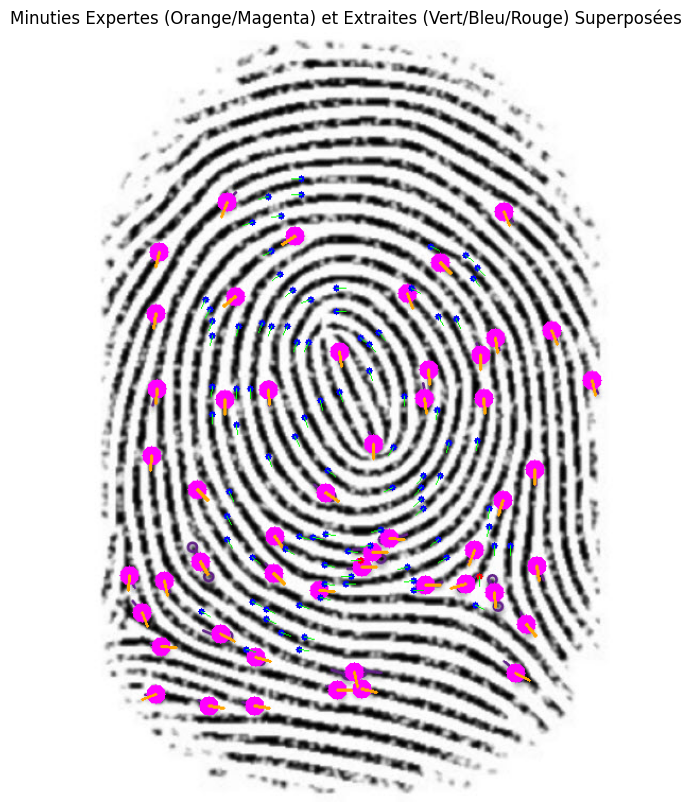

In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Make a copy of the expert reference image to draw on
# This ensures the original image is not modified
combined_minutiae_image = expert_reference_image.copy()

# Draw expert minutiae on the image
# draw_expert_minutiae returns a new image with drawings, so update combined_minutiae_image
combined_minutiae_image = draw_expert_minutiae(combined_minutiae_image, expert_minutiae_with_orientation, line_len=15, line_thickness=2)

# Draw scaled refined minutiae on the same image
# Ensure the refined minutiae are scaled correctly and the function takes a BGR image
combined_minutiae_image = draw_refined_minutiae(combined_minutiae_image, scaled_refined_minutiae, line_len=10, line_thickness=1)

# Display the combined image
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(combined_minutiae_image, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
plt.title('Minuties Expertes (Orange/Magenta) et Extraites (Vert/Bleu/Rouge) Superposées')
plt.axis('off')
plt.show()

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Calculate scaling factors to match 'img' dimensions ---

# Get dimensions of the original image from which 'refined_minutiae' were extracted
img_height, img_width = img.shape[:2]

# Get dimensions of the expert reference image
expert_height, expert_width = expert_reference_image.shape[:2]

# Calculate individual scaling factors for x and y to map from expert image scale to original img scale
scaling_factor_to_img_x = img_width / expert_width
scaling_factor_to_img_y = img_height / expert_height

print(f"Dimensions de l'image originale (pour les minuties extraites): {img_width}x{img_height}")
print(f"Dimensions de l'image experte (pour les minuties expertes): {expert_width}x{expert_height}")
print(f"Facteur d'échelle X pour expert vers original: {scaling_factor_to_img_x:.4f}")
print(f"Facteur d'échelle Y pour expert vers original: {scaling_factor_to_img_y:.4f}")

# --- Step 2: Apply scaling to expert_minutiae_with_orientation ---
rescaled_expert_minutiae = []
for m in expert_minutiae_with_orientation:
    rescaled_expert_minutiae.append({
        'x': int(m['x'] * scaling_factor_to_img_x),
        'y': int(m['y'] * scaling_factor_to_img_y),
        'angle': m['angle'] # Angle doesn't change with uniform scaling
    })

print(f"Nombre de minuties expertes redimensionnées: {len(rescaled_expert_minutiae)}")
print("5 premières minuties expertes redimensionnées:")
for i, m in enumerate(rescaled_expert_minutiae[:5]):
    print(f"  Minutie {i+1}: X={m['x']}, Y={m['y']}, Angle={m['angle']:.4f} radians")

Dimensions de l'image originale (pour les minuties extraites): 275x400
Dimensions de l'image experte (pour les minuties expertes): 506x726
Facteur d'échelle X pour expert vers original: 0.5435
Facteur d'échelle Y pour expert vers original: 0.5510
Nombre de minuties expertes redimensionnées: 51
5 premières minuties expertes redimensionnées:
  Minutie 1: X=90, Y=349, Angle=0.1405 radians
  Minutie 2: X=66, Y=349, Angle=0.1865 radians
  Minutie 3: X=39, Y=343, Angle=2.7529 radians
  Minutie 4: X=132, Y=341, Angle=0.0607 radians
  Minutie 5: X=145, Y=341, Angle=0.2561 radians


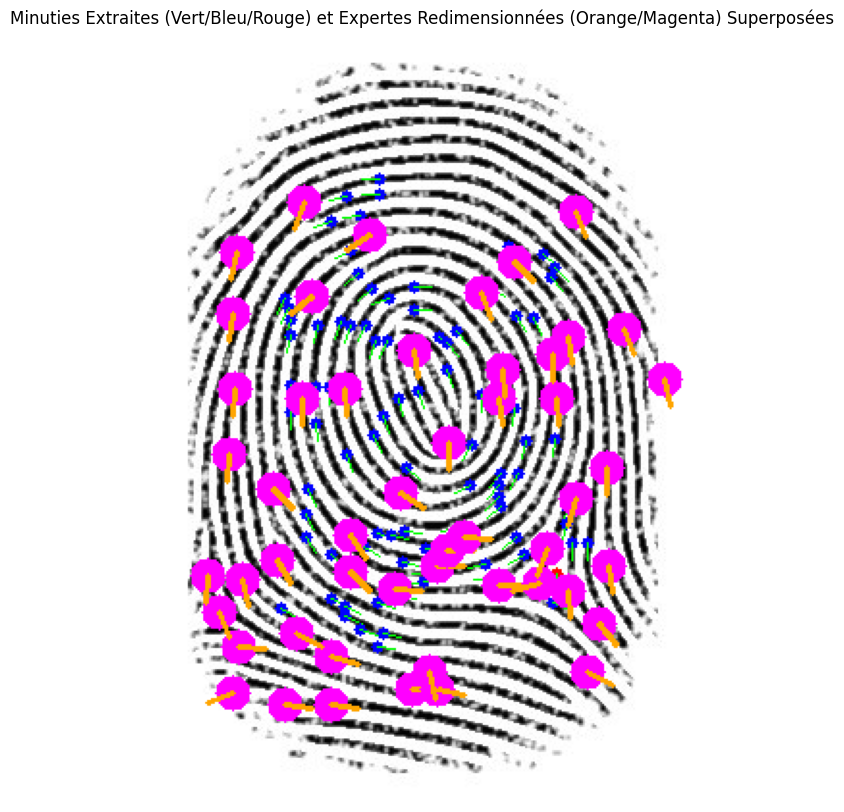

In [46]:
# --- Step 3: Create a new visualization on 'img' as canvas ---

# Convert the original 'img' (grayscale) to BGR to draw colored minutiae
img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Draw the original refined_minutiae (already in 'img's scale)
# Assuming draw_refined_minutiae is defined and expects 'refined_minutiae'
visualization_canvas = draw_refined_minutiae(img_bgr.copy(), refined_minutiae, line_len=10, line_thickness=1)

# Draw the newly rescaled_expert_minutiae on the same canvas
# Assuming draw_expert_minutiae is defined and expects 'expert_minutiae_with_orientation' format
visualization_canvas = draw_expert_minutiae(visualization_canvas, rescaled_expert_minutiae, line_len=15, line_thickness=2)

# Display the combined image
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(visualization_canvas, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
plt.title('Minuties Extraites (Vert/Bleu/Rouge) et Expertes Redimensionnées (Orange/Magenta) Superposées')
plt.axis('off')
plt.show()

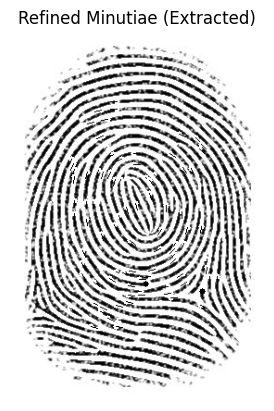

In [47]:
vis_refined_minutiae = draw_refined_minutiae(img, refined_minutiae)
show(vis_refined_minutiae, "Refined Minutiae (Extracted)")